# Interactive Dataset Exploration

This notebook loads a configuration file and creates an InterventionalDataset for exploration.

In [24]:
import sys
import os
import yaml
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from priordata_processing.Datasets.InterventionalDataset import InterventionalDataset

## Load Configuration

In [2]:
# Load the config file
config_path = "experiments/GraphConditioning/configs/five_nodes_lingaus_ultimate_gcn_and_hard_attention.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Config loaded successfully!")
print(f"Experiment: {config['experiment_name']}")
print(f"Mode: {config['mode']}")

Config loaded successfully!
Experiment: two_nodes_lingaus_ultimate_gcn_and_soft_attention
Mode: interventional


## Extract Configurations

In [3]:
# Extract the three main configs needed for the dataset
scm_config = config['scm_config']
dataset_config = config['dataset_config']
preprocessing_config = config['preprocessing_config']

print("SCM Config keys:", list(scm_config.keys()))
print("Dataset Config keys:", list(dataset_config.keys()))
print("Preprocessing Config keys:", list(preprocessing_config.keys()))

SCM Config keys: ['num_nodes', 'graph_edge_prob', 'graph_seed', 'xgboost_prob', 'mechanism_seed', 'mlp_nonlins', 'mlp_num_hidden_layers', 'mlp_hidden_dim', 'mlp_activation_mode', 'mlp_use_batch_norm', 'xgb_node_shape', 'xgb_num_hidden_layers', 'xgb_hidden_dim', 'xgb_activation_mode', 'xgb_use_batch_norm', 'xgb_n_training_samples', 'xgb_add_noise', 'random_additive_std', 'exo_std_distribution', 'endo_std_distribution', 'exo_std_mean', 'exo_std_std', 'endo_std_mean', 'endo_std_std', 'endo_p_zero', 'noise_mixture_proportions', 'use_exogenous_mechanisms', 'mechanism_generator_seed']
Dataset Config keys: ['dataset_size', 'max_number_samples_per_dataset', 'max_number_train_samples_per_dataset', 'max_number_test_samples_per_dataset', 'n_test_samples_per_dataset', 'return_adjacency_matrix', 'min_target_variance', 'max_resample_attempts', 'max_number_features', 'seed']
Preprocessing Config keys: ['dropout_prob', 'shuffle_data', 'target_feature', 'feature_standardize', 'feature_negative_one_one_

## Create Dataset

We'll create a small dataset for exploration with `return_scm=True` to access the SCM and processor.

In [61]:
# Override dataset size to make it smaller for exploration
dataset_config_small = dataset_config.copy()
dataset_config_small['dataset_size'] = {'value': 10}  # Just 10 samples
dataset_config_small['return_adjacency_matrix'] = {'value': True}  # Enable adjacency matrix

# Create dataset with debugging enabled
dataset = InterventionalDataset(
    scm_config=scm_config,
    preprocessing_config=preprocessing_config,
    dataset_config=dataset_config_small,
    seed=42,
    return_scm=True  # This returns (data, adjacency, scm, processor, intervention_node)
)

print(f"Dataset created with {len(dataset)} samples")

Dataset created with 10 samples


In [83]:
X_obs, T_obs, Y_obs, X_intv, T_intv, Y_intv, adj, scm, processor, intervention_node = dataset[9]  # Access the first sample to trigger data generation

obs_data = torch.cat([T_obs, Y_obs, X_obs], dim=1)

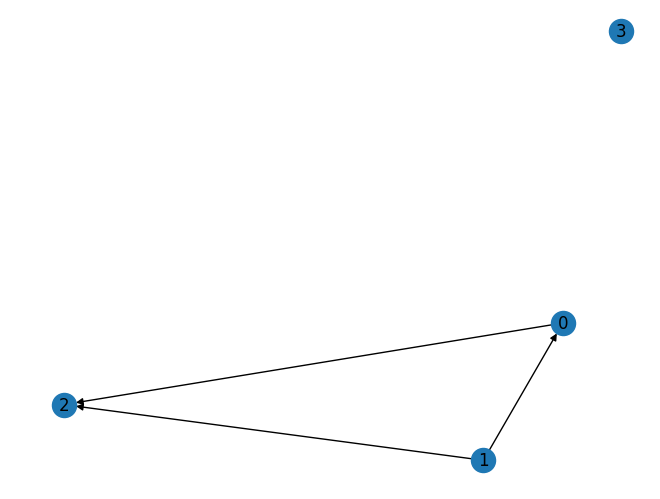

In [84]:
scm.dag.draw()  # Visualize the SCM DAG

In [85]:
processor.intervened_feature, processor.selected_target_feature, processor.kept_feature_indices

(3, 1, [0, 2])

In [86]:
adj

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 1., 1., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

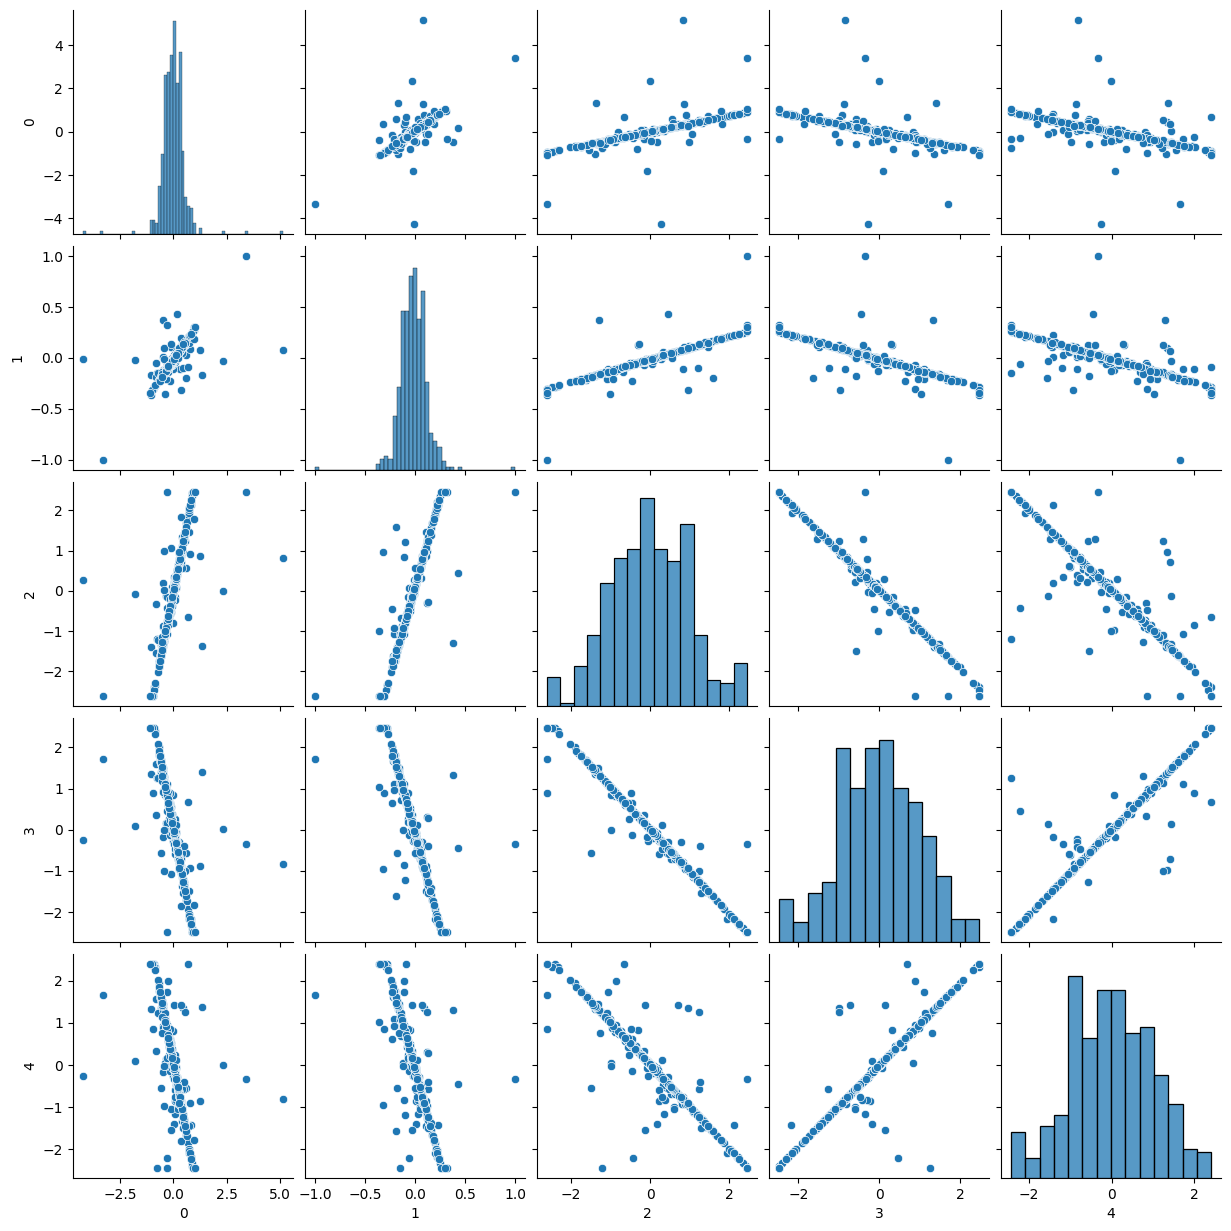

In [76]:
sns.pairplot(pd.DataFrame(obs_data.numpy()))